In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import thư viện

In [120]:
df = pd.read_csv("../data/telco_churn.csv")

load dữ liệu

In [121]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


5 dòng đầu

In [122]:
df.shape

(7043, 21)

Kích thước dữ liệu (7043 dòng, 21 cột)

In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Tên cột, kiểu dữ liệu

In [124]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Kiểm tra tổng số dữ liệu null

In [125]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Sự phân bố của dữ liệu


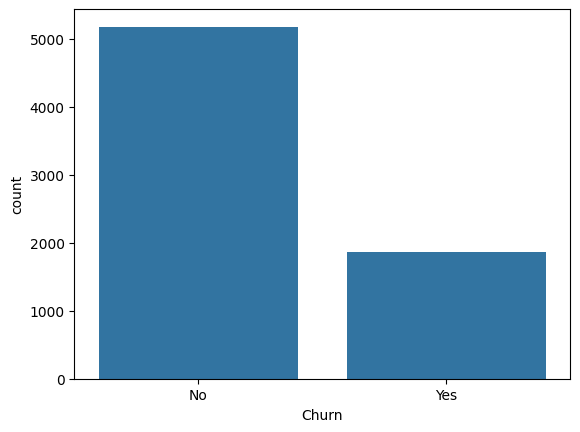

In [126]:
sns.countplot(x="Churn", data=df)
plt.show()

churn ít hơn non-churn nhiều

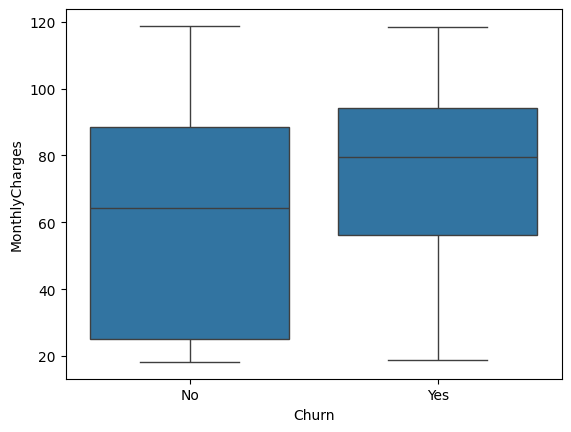

In [127]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.show()

Khách có monthly charges cao có xu hướng churn nhiều hơn

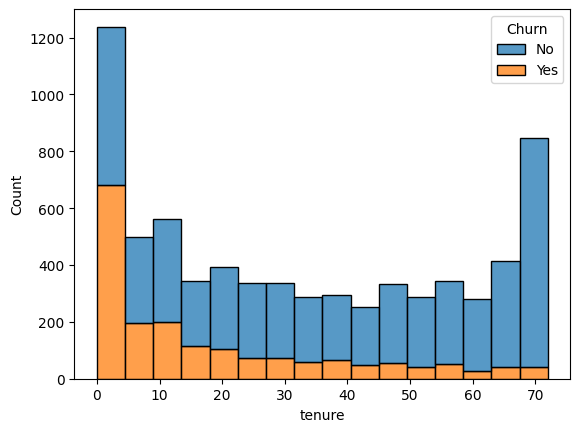

In [128]:
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    multiple="stack"
)

plt.show()

Khách hàng mới thường có xu hướng churn nhiều hơn

In [129]:
df["TotalCharges"]

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: str

chuyển total charges sang kiểu dữ liệu numeric và điền giá trị thiếu thành giá trị trung vị nếu có

In [130]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

Điền giá trị thiếu thành giá trị trung vị nếu có

Gán nhãn cho churn

In [131]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

Xóa cột customerID để cho giảm thiểu kích thước dữ liệu giúp mô hình học tốt hơn

In [132]:
df.drop("customerID", axis=1, inplace=True)

One hot encoding

In [133]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [134]:
df.to_csv(
    "../processed/cleaned_data.csv",
    index=False
)

Dữ liệu sau khi one hot encoding

In [135]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


Tách features và target

In [136]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

Chia dữ liệu 80% để train và 20% để test

In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Lưu lại tập train, test để tái sử dụng

In [138]:
X_train.to_csv(
    "../processed/X_train.csv",
    index=False
)

X_test.to_csv(
    "../processed/X_test.csv",
    index=False
)

y_train.to_csv(
    "../processed/y_train.csv",
    index=False
)

y_test.to_csv(
    "../processed/y_test.csv",
    index=False
)

In [146]:
import joblib


joblib.dump(
    X_train,
    "../processed/X_train.pkl"
)

joblib.dump(
    X_test,
    "../processed/X_test.pkl"
)

joblib.dump(
    y_train,
    "../processed/y_train.pkl"
)

joblib.dump(
    y_test,
    "../processed/y_test.pkl"
)

['../processed/y_test.pkl']

Kích thước của tập train và test sau khi chia

In [139]:
print(f"Kích thước tập train: {X_train.shape}")

print(f"Kích thước tập test: {X_test.shape}")

Kích thước tập train: (5634, 30)
Kích thước tập test: (1409, 30)


Training model với LogisticRegression

In [140]:
import joblib

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

joblib.dump(model, "../models/logistic_regression_model.pkl")

d:\customer-churn-ai\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


['../models/logistic_regression_model.pkl']

Đánh giá model

Dự đoán

In [141]:
y_pred = model.predict(X_test)

Accuracy

In [142]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.8211497515968772


Classification report

In [143]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



Confusion matrix

In [144]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[933 103]
 [149 224]]


Heatmap

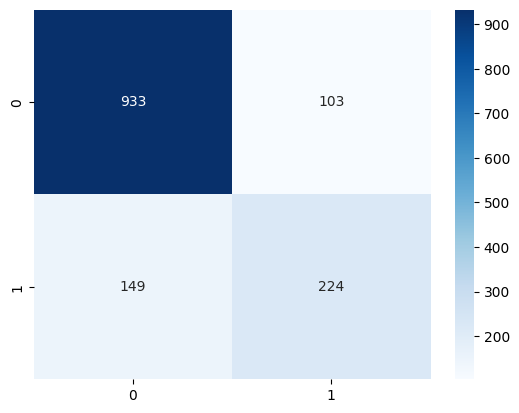

In [145]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.show()